<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# DS2-LAB-01
## Guilherme Kastner


Usar o arquivo da regressão com variáveis categóricas e aplicar o k-fold.


## Bibliotecas

In [149]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelBinarizer

# importando as bibliotecas do matplotlib para gerar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importando a biblioteca numpy e math que fornece funções matemáticas básicas
import numpy as np
import math 

# Importando biblioteca do seaborn para gerar gráficos mais atraentes e informativos
import seaborn as sns

# Importando a classe LinearRegression do sklearn 
# Essa classe implementa uma versão da regressão linear simples ou múltipla
# Usado para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score


# Usado para exibir os gráficos gerados pela biblioteca Matplotlib diretamente no notebook, sem precisar abrir uma janela externa.
%matplotlib inline


## Obtendo dados

In [150]:
# Caminho do arquivo csv
caminho = "MeuAutoLimpo.csv" 

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho) 

df.head()

#print(df)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,164,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


## Regressão Linear Com Variáveis Categóricas

### Variáveis Dicotômicas 

In [151]:
df_dummy_dicotomica = df[['price','engine-size', 'curb-weight','num-of-doors']].copy(deep=True)

df_dummy_dicotomica = df_dummy_dicotomica.rename(columns={'num-of-doors':'num_of_doors'})

df_dummy_dicotomica.head()

,price,engine-size,curb-weight,num_of_doors
0,13495,130,2548,two
1,16500,130,2548,two
2,16500,152,2823,two
3,13950,109,2337,four
4,17450,136,2824,four


In [152]:
label_binarizer = LabelBinarizer()
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html

dicotomica = df_dummy_dicotomica['num_of_doors']
label_binarizer.fit(dicotomica)
df_dummy_dicotomica['num_of_doors'] = label_binarizer.transform(dicotomica)

In [153]:
df_dummy_dicotomica.head(20)

,price,engine-size,curb-weight,num_of_doors
0,13495,130,2548,1
1,16500,130,2548,1
2,16500,152,2823,1
3,13950,109,2337,0
4,17450,136,2824,0
5,15250,136,2507,1
6,17710,136,2844,0
7,18920,136,2954,0
8,23875,131,3086,0
9,16430,108,2395,1


In [154]:
lm = LinearRegression()

(lm)

LinearRegression()

### Aplicação do K-fold

In [179]:
from sklearn.model_selection import KFold


# Separate features and target variable
X = df_dummy_dicotomica.drop(columns=['price'])
y = df_dummy_dicotomica['price']

# Initialize lists to store the MSE for each fold
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []


# kf = KFold(n_splits=2, random_state=45, shuffle=True)

#print(kf)
# Retirado da documentação do sklearn
# https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.KFold.html

splits = 50

y_true_all = []
y_pred_all = []


kf = KFold(n_splits=splits, random_state=45, shuffle=True)
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

    # calcular o MAE, MSE, MAPE e R2 para cada fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    lm.fit(X_train, y_train)
    y_pred = lm.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = lm.score(X_test, y_test)
    # Acumula os valores de todos os folds
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(r2)
    print(f"  MSE: {mse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}, R2: {r2:.2f}\n")
    
# Exibir os resultados médios
print(f"Average MSE: {np.mean(mse_scores):.2f}")
print(f"Average MAE: {np.mean(mae_scores):.2f}")
print(f"Average MAPE: {np.mean(mape_scores):.2f}")
print(f"Average R2: {np.mean(r2_scores):.2f}")


Fold 0:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  41  42  43  44  46  47  48  49  50  51  52  53  54  55  56
  57  59  60  61  62  63  64  65  66  67  68  69  70  71  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130
 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148
 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200]
  Test:  index=[25 40 45 58 72]
  MSE: 2525899.96, MAE: 1326.42, MAPE: 0.13, R2: 0.97

Fold 1:
  Train: index=[  0   1   2   4   5   6   7   8   9  10  11  12  14  15  16  17  18  1

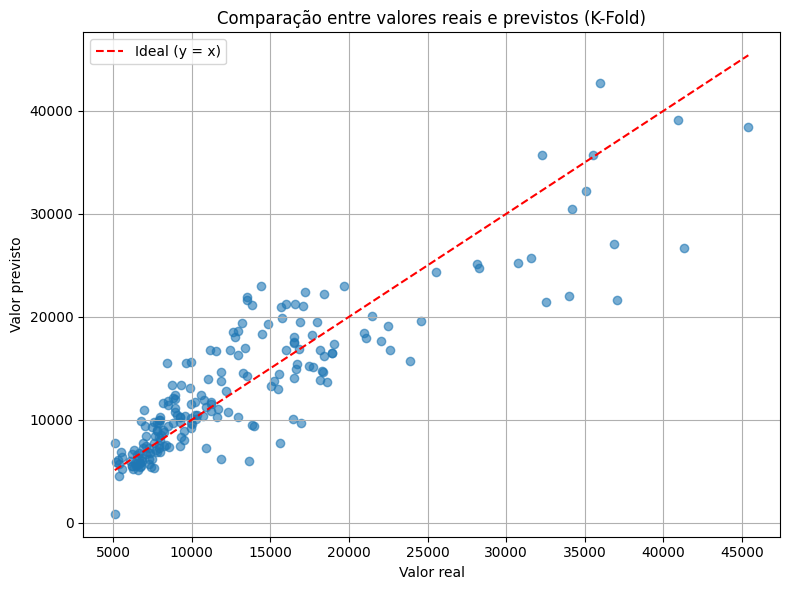

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.6)
plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'r--', label="Ideal (y = x)")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Comparação entre valores reais e previstos (K-Fold)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




Text(0.5, 0, 'Resíduo (em dollars)')

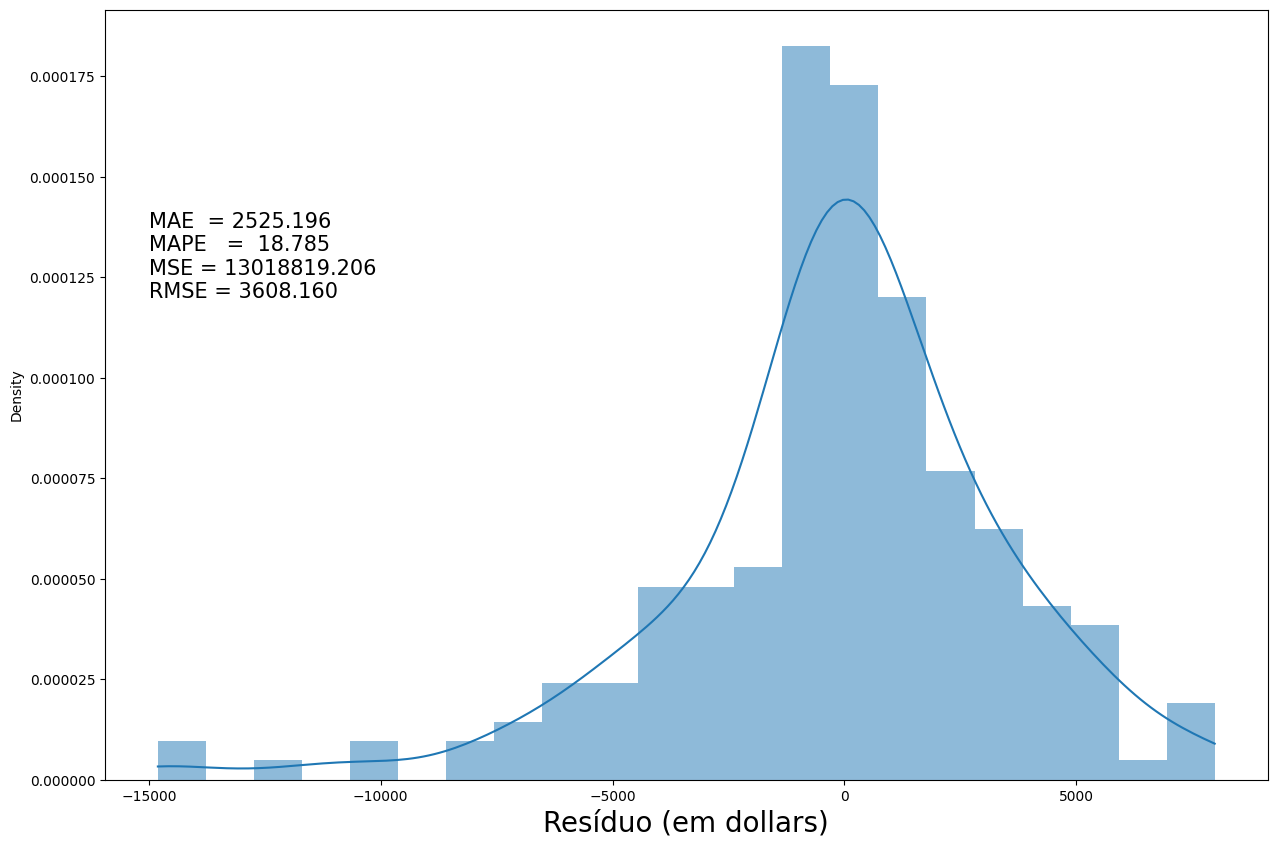

In [157]:
# Erro
y_train = df_dummy_dicotomica['price']
y_pred  = lm.predict(X)

mae = mean_absolute_error(y_train, y_pred)
mape = 100*mean_absolute_percentage_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)

plt.figure(figsize=(15, 10))

tt = "MAE  = %.3f \nMAPE   =  %.3f \nMSE = %.3f \nRMSE = %.3f" % (mae,mape,mse,rmse)

sns.histplot(x=y_pred-df_dummy_dicotomica['price'], kde=True, stat="density", linewidth=0)
plt.text(-15000, 0.00012, tt, size=15, color = "black")
plt.xlabel('Resíduo (em dollars)', size = 20)

In [158]:
X = df_dummy_dicotomica[df_dummy_dicotomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_dicotomica['price']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

# Carregando o modelo
lm.fit(X_train, y_train)

# Exibindo o R^2
R2_train=lm.score(X_train, y_train)
R2_test=lm.score(X_test, y_test)

print("SCORE Train: %.4f \nSCORE Test: %.4f" % (R2_train,R2_test))

SCORE Train: 0.8076 
SCORE Test: 0.7362


### Variáveis Politômicas

In [159]:
lm = LinearRegression()
lm

LinearRegression()

In [160]:
df_dummy_politomica = df[['price','engine-size', 'curb-weight','make']].copy(deep=True)

df_dummy_politomica.head()

,price,engine-size,curb-weight,make
0,13495,130,2548,alfa-romero
1,16500,130,2548,alfa-romero
2,16500,152,2823,alfa-romero
3,13950,109,2337,audi
4,17450,136,2824,audi


## Verificando os valores e corrigindo os "duplicados"

In [161]:
df_categorias_make = pd.DataFrame({'cat': df_dummy_politomica['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,bmw
3,BMW
4,chevrolet
5,dodge
6,doge
7,honda
8,isuzu
9,jaguar


In [162]:
df_dummy_politomica['make'].unique()

array(['alfa-romero', 'audi', 'bmw', 'BMW', 'chevrolet', 'dodge', 'doge',
       'honda', 'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'VW', 'volv1', 'volvo'],
      dtype=object)

In [163]:
df_dummy_politomica['make'] = df_dummy_politomica['make'].replace({'bmw': 'BMW'})

In [164]:
df_categorias_make = pd.DataFrame({'cat': df_dummy_politomica['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,BMW
3,chevrolet
4,dodge
5,doge
6,honda
7,isuzu
8,jaguar
9,mazda


In [165]:
df_dummy_politomica['make'] = df_dummy_politomica['make'].replace({'doge': 'dodge', 'VW':'volkswagen', 'volv1':'volvo' })

df_categorias_make = pd.DataFrame({'cat': df_dummy_politomica['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,BMW
3,chevrolet
4,dodge
5,honda
6,isuzu
7,jaguar
8,mazda
9,mercedes-benz


In [166]:
# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(df_dummy_politomica[['make']])

# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out(['make']))

# Concatene o DataFrame dummy com os outros dados
df_dummy_politomica = pd.concat([df_dummy_politomica.drop('make', axis=1), dummy_df], axis=1)

df_dummy_politomica.head()

,price,engine-size,curb-weight,make_BMW,make_alfa-romero,make_audi,make_chevrolet,make_dodge,make_honda,make_isuzu,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
0,13495,130,2548,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16500,130,2548,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,16500,152,2823,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13950,109,2337,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17450,136,2824,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [167]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

# Carregando o modelo
lm.fit(X, Y)

# Exibindo o R^2
R2=lm.score(X,Y)

print("SCORE: %.4f" % R2)

SCORE: 0.9279


Text(45000, 3.3e-05, 'SCORE: 0.927893')

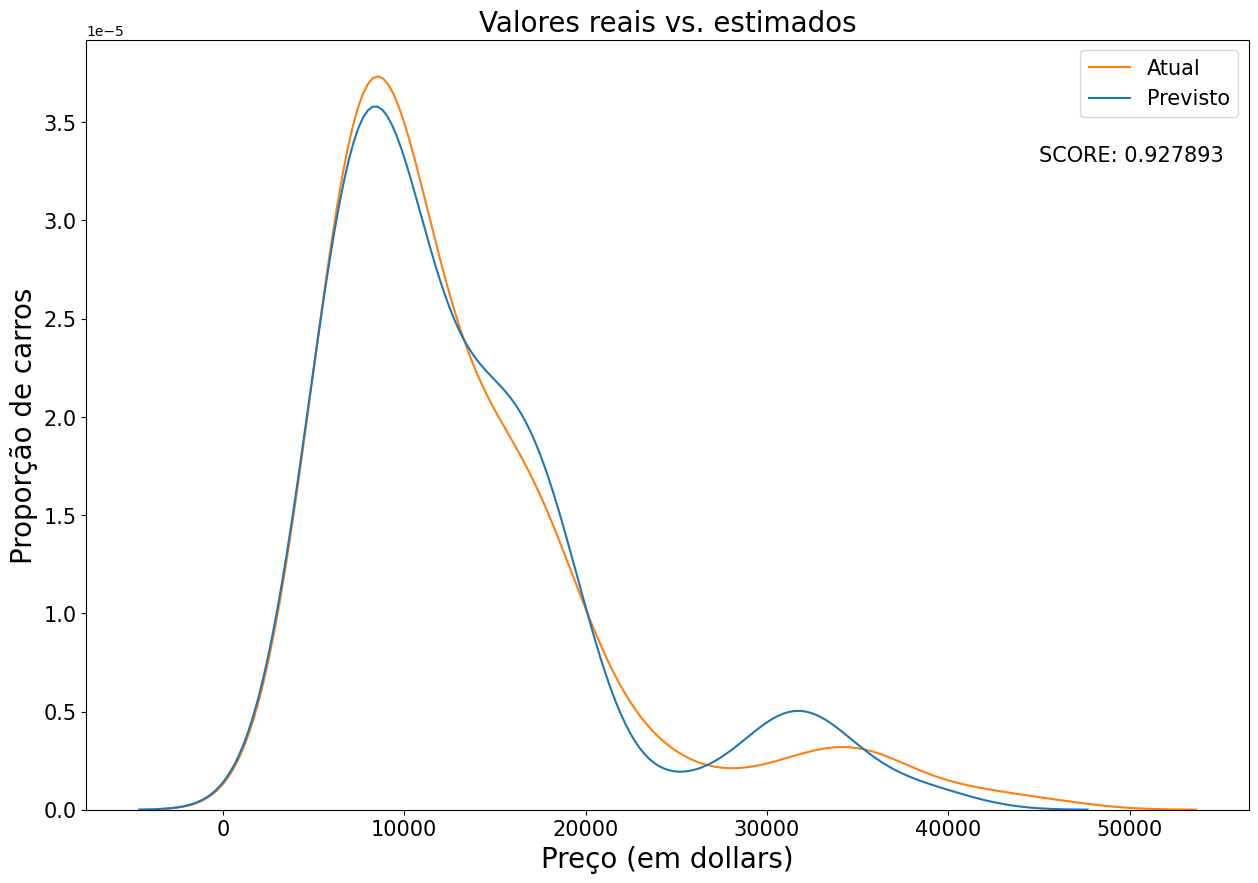

In [168]:
plt.figure(figsize=(15, 10))

sns.kdeplot(data = [lm.predict(X),df_dummy_politomica['price']])

plt.title('Valores reais vs. estimados', size = 20)
plt.xlabel('Preço (em dollars)', size = 20)
plt.ylabel('Proporção de carros', size = 20)
plt.yticks(size = 15)
plt.xticks(size = 15) 
plt.legend(labels=["Atual","Previsto"], fontsize = 15, bbox_to_anchor=(1, 1))

tt = "SCORE: %4f" % R2

plt.text(45000, 0.000033, tt, size = 15)

Text(0.5, 0, 'Resíduo (em dollars)')

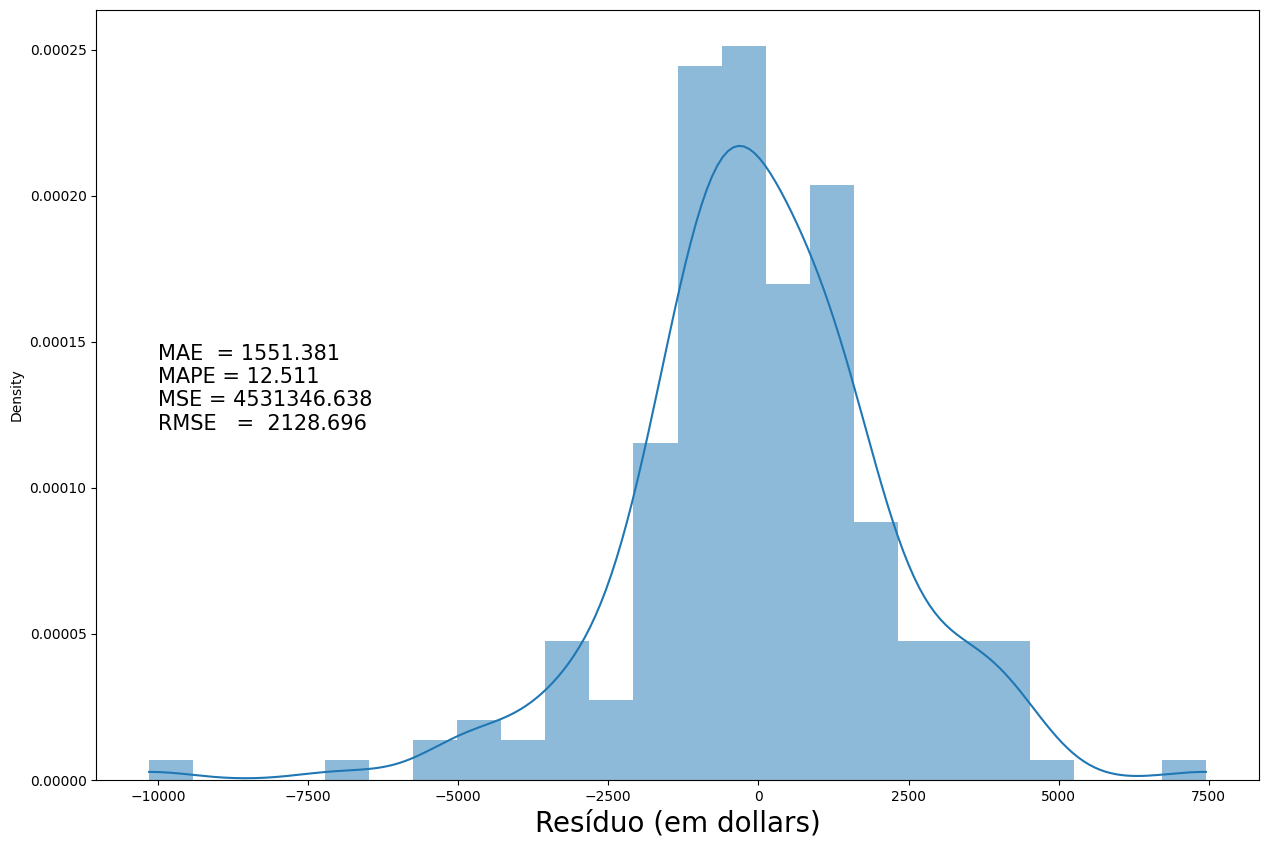

In [169]:
y_train = df_dummy_politomica['price']
y_pred  = lm.predict(X)

mae = mean_absolute_error(y_train, y_pred)
mape = 100*mean_absolute_percentage_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)

plt.figure(figsize=(15, 10))

tt = "MAE  = %.3f \nMAPE = %.3f \nMSE = %.3f \nRMSE   =  %.3f" % (mae, mape, mse, rmse)

sns.histplot(x=y_pred-df_dummy_politomica['price'], kde=True, stat="density", linewidth=0)
plt.text(-10000, 0.00012, tt, size=15, color = "black")
plt.xlabel('Resíduo (em dollars)', size = 20)

In [170]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

# Carregando o modelo
lm.fit(X_train, y_train)

# Exibindo o R^2
R2_train=lm.score(X_train, y_train)
R2_test=lm.score(X_test, y_test)

print("SCORE Train: %.4f \nSCORE Test: %.4f" % (R2_train,R2_test))

SCORE Train: 0.9295 
SCORE Test: 0.9086


### Utilizando todas as variáveis

In [171]:
cat = ['object']
df_cat = df.select_dtypes(include=cat)
df_cat

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
196,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
197,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
198,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
199,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [172]:
for col in df_cat.columns:
    print(col,df_cat[col].unique())

#mudar make
#'bmw', 'BMW'
#'dodge', 'doge'
#'volkswagen', 'VW'
#'volv1', 'volvo'

make ['alfa-romero' 'audi' 'bmw' 'BMW' 'chevrolet' 'dodge' 'doge' 'honda'
 'isuzu' 'jaguar' 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan'
 'peugot' 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota'
 'volkswagen' 'VW' 'volv1' 'volvo']
fuel-type ['gas' 'diesel']
aspiration ['std' 'turbo']
num-of-doors ['two' 'four']
body-style ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drive-wheels ['rwd' 'fwd' '4wd']
engine-location ['front' 'rear']
engine-type ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf']
num-of-cylinders ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
fuel-system ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [173]:
df_cat['make'] = df_cat['make'].replace({'bmw': 'BMW','doge':'dodge','volkswagen':'VW','volvo':'volv1'})

In [174]:
# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(df_cat)

# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out())

# Concatene o DataFrame dummy com os outros dados
df_dummy_politomica = pd.concat([df.drop(df.select_dtypes(include=cat).columns, axis=1), dummy_df], axis=1)

df_dummy_politomica.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,164,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [175]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

# Carregando o modelo
lm.fit(X, Y)

# Exibindo o R^2
R2=lm.score(X,Y)

print("SCORE: %.4f" % R2)

SCORE: 0.9673


Text(45000, 3.3e-05, 'SCORE: 0.967304')

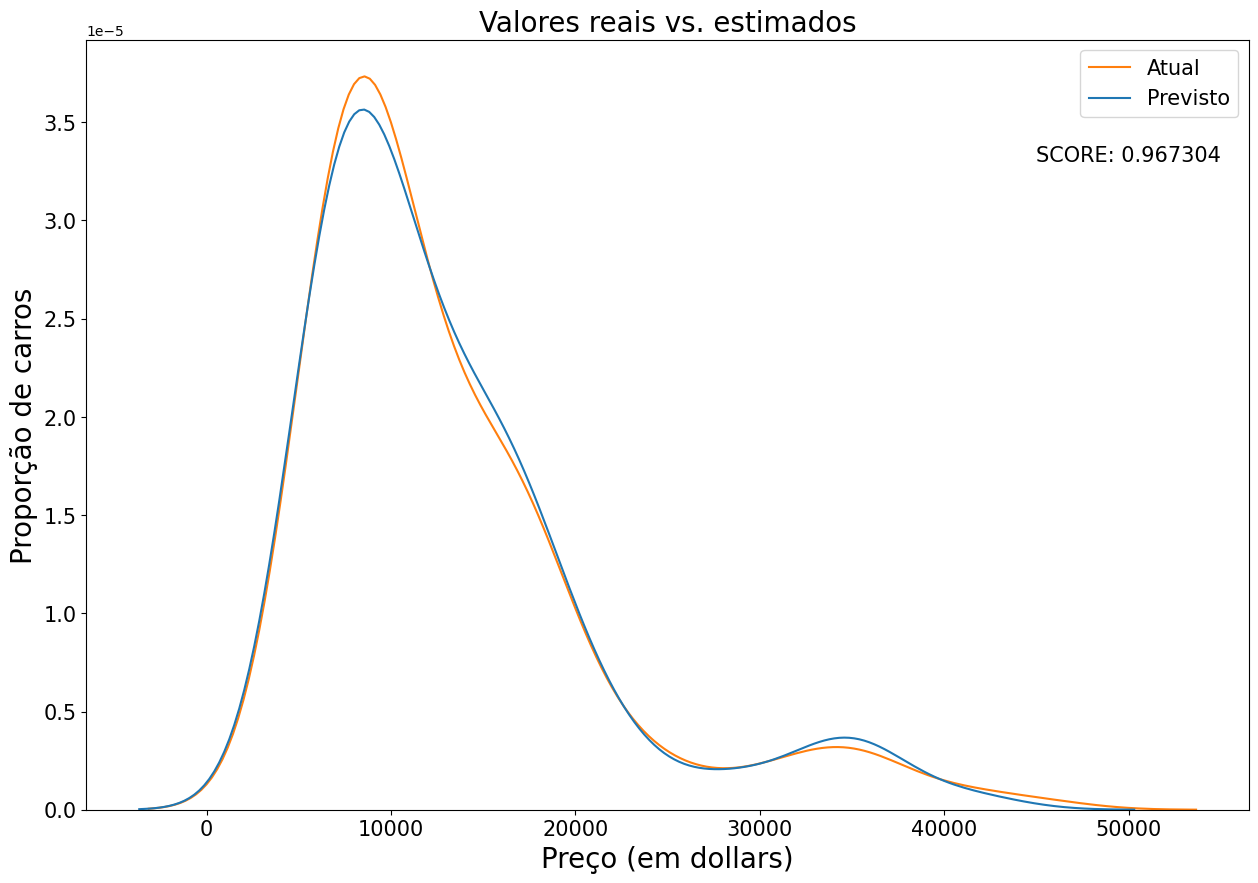

In [176]:
plt.figure(figsize=(15, 10))

sns.kdeplot(data = [lm.predict(X),df_dummy_politomica['price']])

plt.title('Valores reais vs. estimados', size = 20)
plt.xlabel('Preço (em dollars)', size = 20)
plt.ylabel('Proporção de carros', size = 20)
plt.yticks(size = 15)
plt.xticks(size = 15) 
plt.legend(labels=["Atual","Previsto"], fontsize = 15, bbox_to_anchor=(1, 1))

tt = "SCORE: %4f" % R2

plt.text(45000, 0.000033, tt, size = 15)

Text(0.5, 0, 'Resíduo (em dollars)')

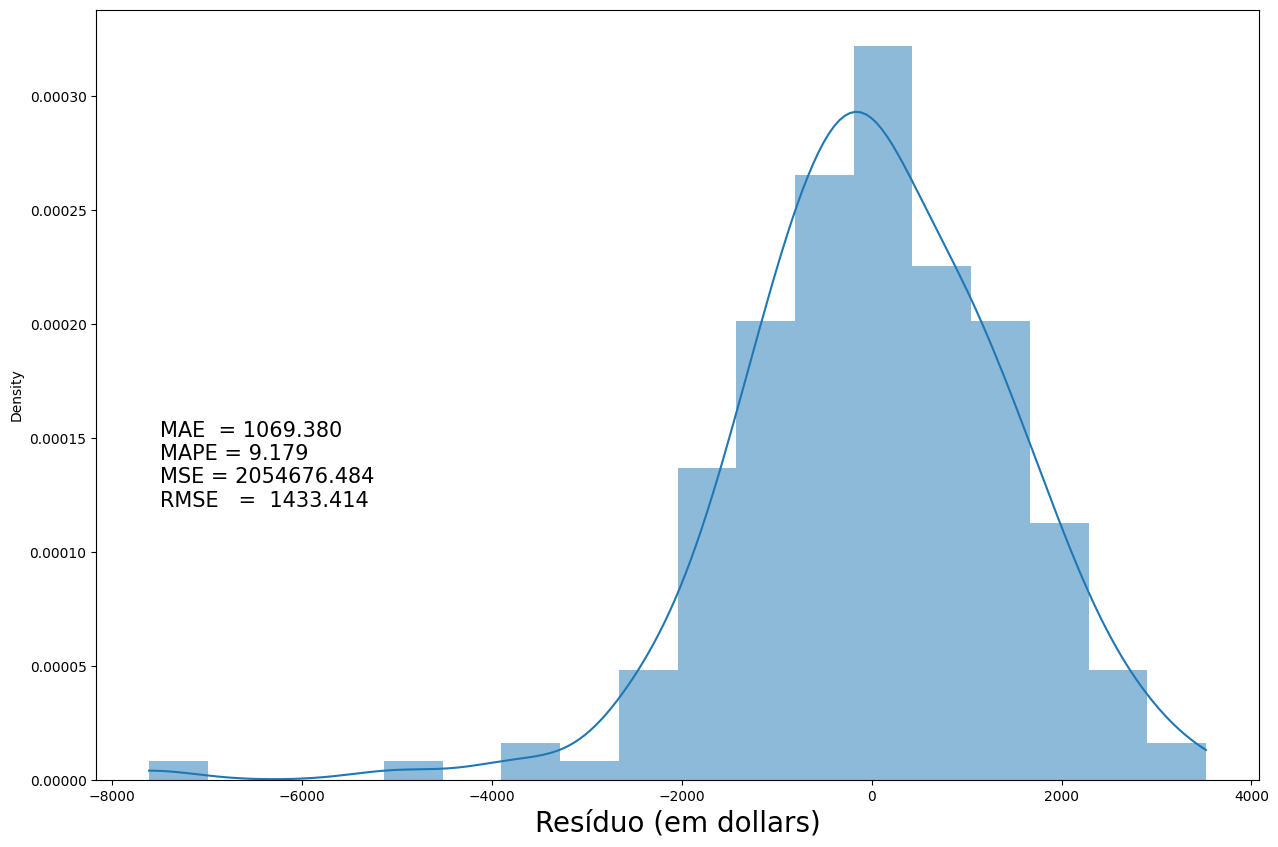

In [177]:
y_train = df_dummy_politomica['price']
y_pred  = lm.predict(X)

mae = mean_absolute_error(y_train, y_pred)
mape = 100*mean_absolute_percentage_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)

plt.figure(figsize=(15, 10))

tt = "MAE  = %.3f \nMAPE = %.3f \nMSE = %.3f \nRMSE   =  %.3f" % (mae, mape, mse, rmse)

sns.histplot(x=y_pred-df_dummy_politomica['price'], kde=True, stat="density", linewidth=0)
plt.text(-7500, 0.00012, tt, size=15, color = "black")
plt.xlabel('Resíduo (em dollars)', size = 20)

In [178]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

# Carregando o modelo
lm.fit(X_train, y_train)

# Predizendo os valores
#df_dummy_politomica.loc[:,'YHat'] = lm.predict(X)

# Exibindo o R^2
R2_train=lm.score(X_train, y_train)
R2_test=lm.score(X_test, y_test)

print("SCORE Train: %.4f \nSCORE Test: %.4f" % (R2_train,R2_test))

SCORE Train: 0.9666 
SCORE Test: 0.8841


## Referências:

Translated and inspired in the material developed by IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>

Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>

Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>

Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Fique Conectado

- [![YouTube](https://img.icons8.com/ios-filled/40/000000/youtube-play.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/ios-filled/40/000000/linkedin.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/ios-filled/40/000000/instagram-new.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>, <a href="https://www.linkedin.com/in/hesauhugocavalcanti/" target="_blank">Hesau Hugo</a> , <a href="https://www.linkedin.com/in/joão-gabriel-santin-botelho/" target="_blank">João Gabriel</a>

## Referências:

Traduzido e inspirado do material desenvolviedo pela IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>
* Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>
* Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 04-04-2021       | 1.0     | Eduardo Pecora    | Inicial               |
| 03-11-2021       | 1.1     | Eduardo Pecora    | Estrutura Aula        |
| 08-03-2022       | 1.2     | Eduardo Pecora    | GitHub                |
| 17-04-2023       | 1.3     | Hesau Hugo        | Reestruturação        |
| 18-09-2024       | 1.4     | João Gabriel      | Atualização           |